In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS AND DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

# Load predicted output
df = pd.read_csv("output/xgb_predicted_all.csv")
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# Re-engineer features for visualization (same logic as feature_engineer.py)
df["expected_sales"]   = df["quantity"] * df["unit_price"]
df["sales_math_error"] = (
    (df["sales_amount"] - df["expected_sales"]).abs()
    / (df["sales_amount"].abs() + 1e-9)
).round(6)
df["sales_per_unit"] = (df["sales_amount"] / (df["quantity"].abs() + 1e-9)).round(6)
df["sales_per_unit_deviation"] = (
    (df["sales_per_unit"] - df["unit_price"]).abs()
    / (df["unit_price"].abs() + 1e-9)
).round(6)
df["is_negative_price"]    = (df["unit_price"] < 0).astype(int)
df["is_zero_quantity"]     = (df["quantity"] == 0).astype(int)
df["is_negative_quantity"] = (df["quantity"] < 0).astype(int)
discount_col = df["discount"].fillna(0) if "discount" in df.columns else 0
df["unauthorized_discount"] = ((discount_col > 0) & (df["is_promotion"] == 0)).astype(int)
qty_stats = df.groupby("product_id")["quantity"].agg(qty_mean="mean", qty_std="std").reset_index()
df = df.merge(qty_stats, on="product_id", how="left")
df["qty_zscore"] = ((df["quantity"] - df["qty_mean"]) / (df["qty_std"] + 1e-9)).abs().round(4)
df["month"]      = df["date"].dt.month.fillna(1).astype(int)
df["month_name"] = df["date"].dt.strftime("%b")

# Separate flagged anomalies (exclude normal rows for most charts)
anomalies_df = df[
    (df["predicted_anomaly"] == 1) &
    (df["predicted_type"] != "normal")
].copy()

# Color palette for anomaly types
TYPE_COLORS = {
    "sales_math_error":      "#e63946",
    "wrong_price":           "#457b9d",
    "negative_unit_price":   "#8338ec",
    "unauthorized_discount": "#f4a261",
    "zero_quantity":         "#06d6a0",
    "quantity_outlier":      "#adb5bd",
}

ANOMALY_TYPES = list(TYPE_COLORS.keys())
PALETTE       = list(TYPE_COLORS.values())

print(f"Rows loaded       : {len(df):,}")
print(f"Anomalies flagged : {len(anomalies_df):,} ({len(anomalies_df)/len(df)*100:.2f}%)")
print(f"Normal rows       : {int((df['predicted_anomaly']==0).sum()):,}")
print(f"\nAnomaly breakdown:")
print(anomalies_df["predicted_type"].value_counts().to_string())



Rows loaded       : 100,768
Anomalies flagged : 1,587 (1.57%)
Normal rows       : 99,181

Anomaly breakdown:
predicted_type
sales_math_error         465
wrong_price              391
negative_unit_price      329
unauthorized_discount    198
zero_quantity            137
quantity_outlier          67


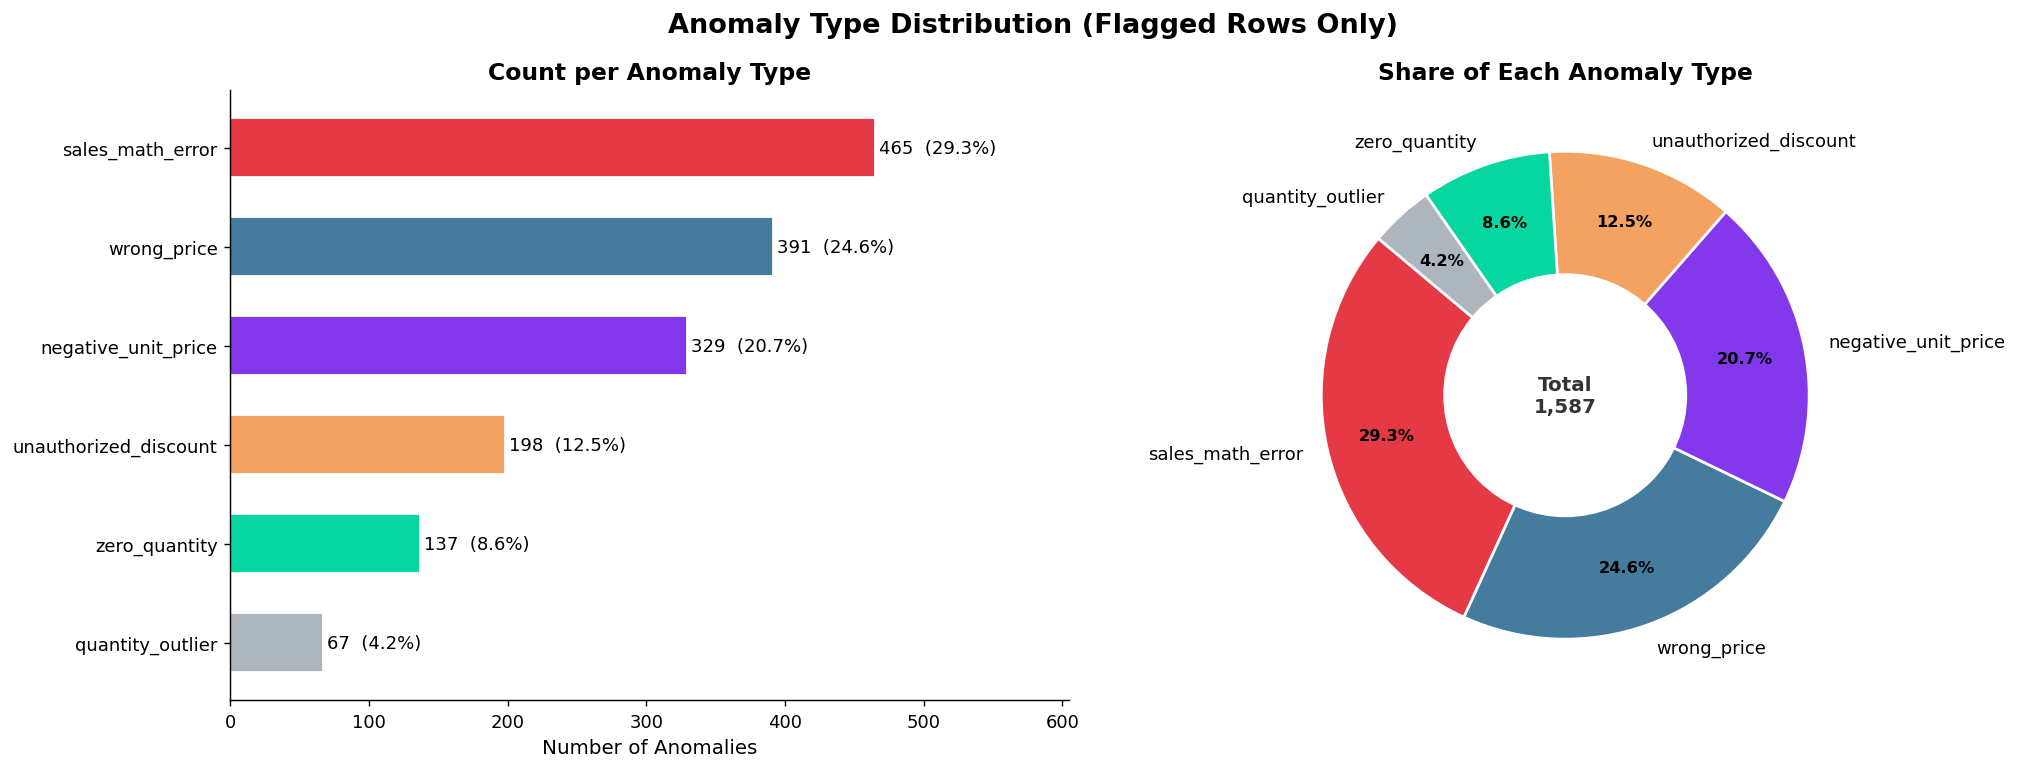

In [9]:

# ═══════════════════════════════════════════════════════════════════════════════
# VIZ 1 — ANOMALY TYPE DISTRIBUTION (anomalies only, no "normal" bar)
# ═══════════════════════════════════════════════════════════════════════════════

type_counts = anomalies_df["predicted_type"].value_counts().sort_values(ascending=True)
total_anomalies = type_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Anomaly Type Distribution (Flagged Rows Only)", fontsize=15, fontweight="bold")

# Left: count bar
colors_left = [TYPE_COLORS.get(t, "#aaa") for t in type_counts.index]
bars = axes[0].barh(type_counts.index, type_counts.values, color=colors_left, edgecolor="white", height=0.6)
axes[0].set_xlabel("Number of Anomalies")
axes[0].set_title("Count per Anomaly Type")
for bar, val in zip(bars, type_counts.values):
    pct = val / total_anomalies * 100
    axes[0].text(val + 3, bar.get_y() + bar.get_height()/2,
                 f"{val}  ({pct:.1f}%)", va="center", fontsize=10)
axes[0].set_xlim(0, type_counts.max() * 1.3)

# Right: percentage donut-style pie
type_counts_sorted = type_counts.sort_values(ascending=False)
colors_right = [TYPE_COLORS.get(t, "#aaa") for t in type_counts_sorted.index]
wedges, texts, autotexts = axes[1].pie(
    type_counts_sorted.values,
    labels=type_counts_sorted.index,
    autopct="%1.1f%%",
    colors=colors_right,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
centre_circle = plt.Circle((0, 0), 0.5, fc="white")
axes[1].add_patch(centre_circle)
axes[1].set_title("Share of Each Anomaly Type")
axes[1].text(0, 0, f"Total\n{total_anomalies:,}", ha="center", va="center",
             fontsize=11, fontweight="bold", color="#333")

plt.tight_layout()
plt.savefig("output/viz_1_anomaly_distribution.png", dpi=150, bbox_inches="tight")
plt.show()



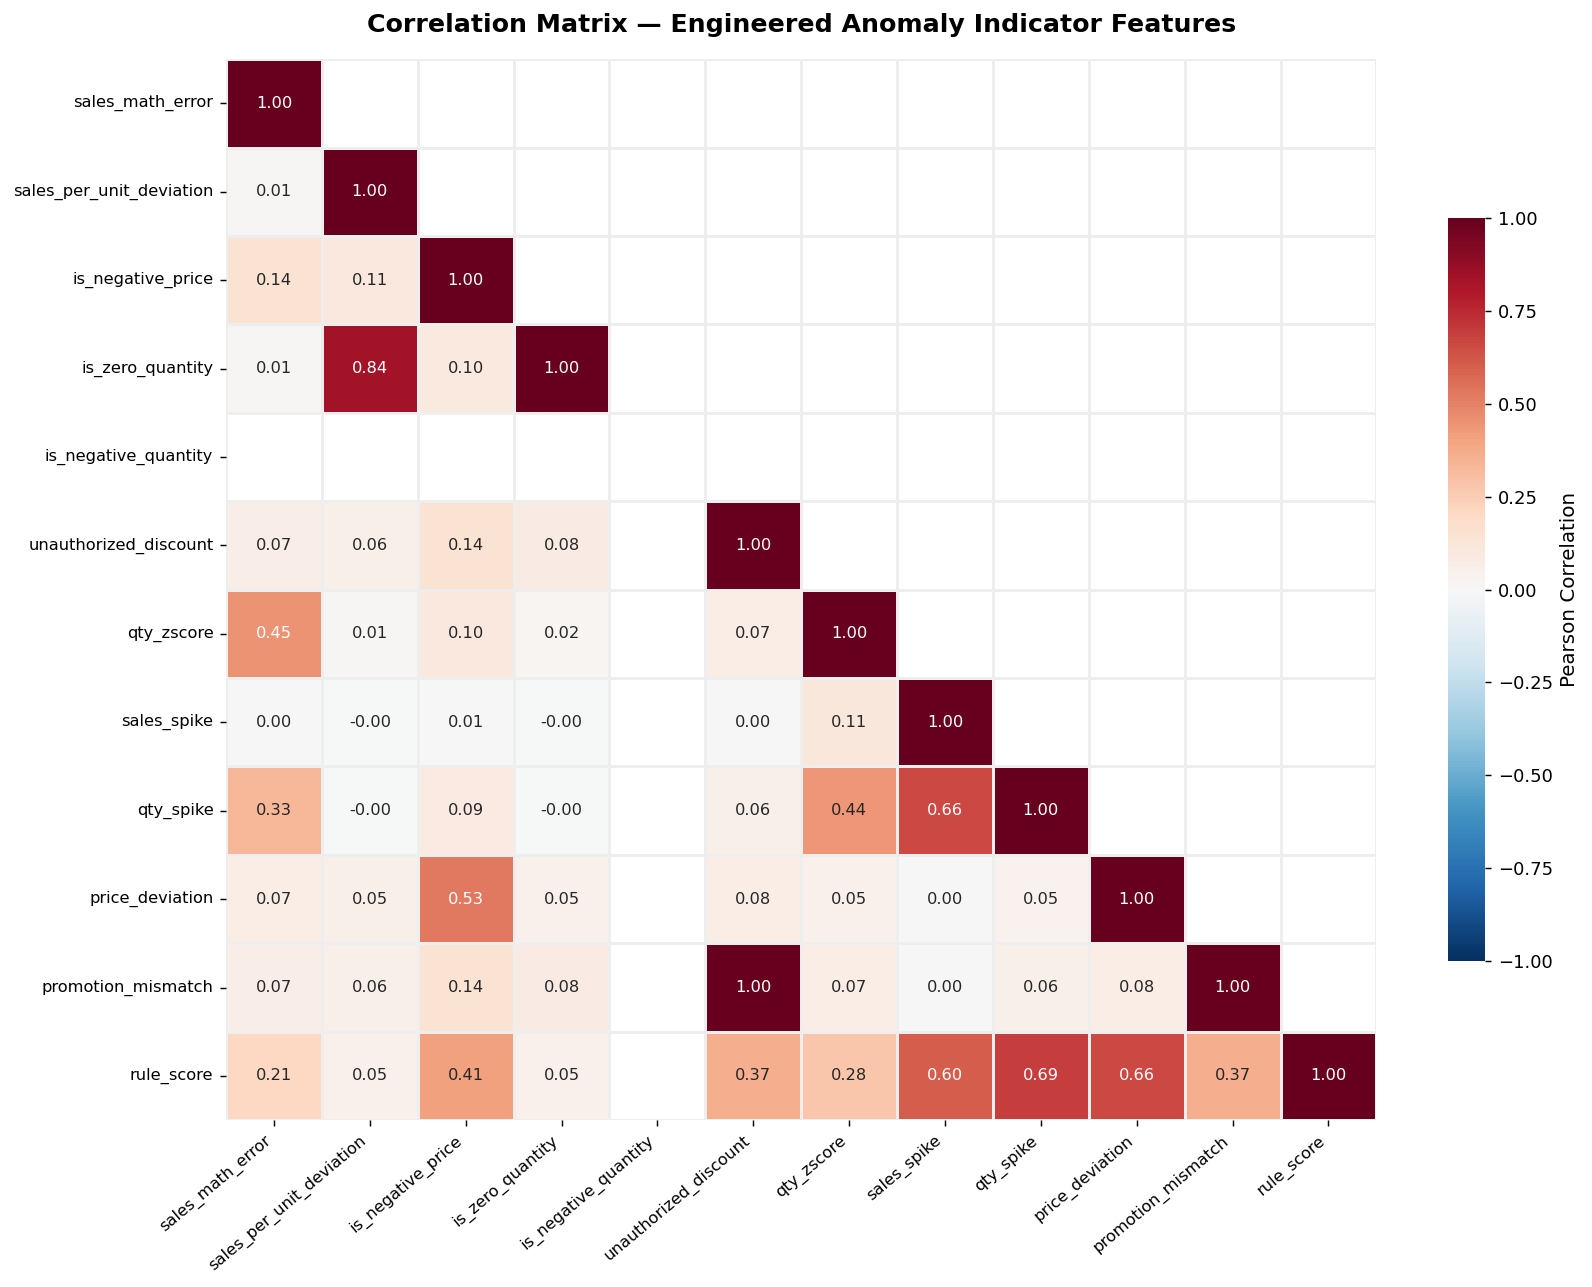

In [10]:

# ═══════════════════════════════════════════════════════════════════════════════
# VIZ 2 — CORRELATION MATRIX: ENGINEERED FEATURES ONLY (lower triangle)
# ═══════════════════════════════════════════════════════════════════════════════

engineered_cols = [
    "sales_math_error", "sales_per_unit_deviation",
    "is_negative_price", "is_zero_quantity", "is_negative_quantity",
    "unauthorized_discount", "qty_zscore",
]
precomputed = ["sales_spike", "qty_spike", "price_deviation",
               "negative_inventory", "promotion_mismatch", "rule_score"]
existing_precomputed = [c for c in precomputed if c in df.columns and df[c].std() > 0]
viz_cols = engineered_cols + existing_precomputed

corr = df[viz_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # keep lower triangle + diagonal

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.6, linecolor="#eee",
    annot_kws={"size": 9},
    cbar_kws={"label": "Pearson Correlation", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Correlation Matrix — Engineered Anomaly Indicator Features",
             fontsize=14, pad=15)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("output/viz_2_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()



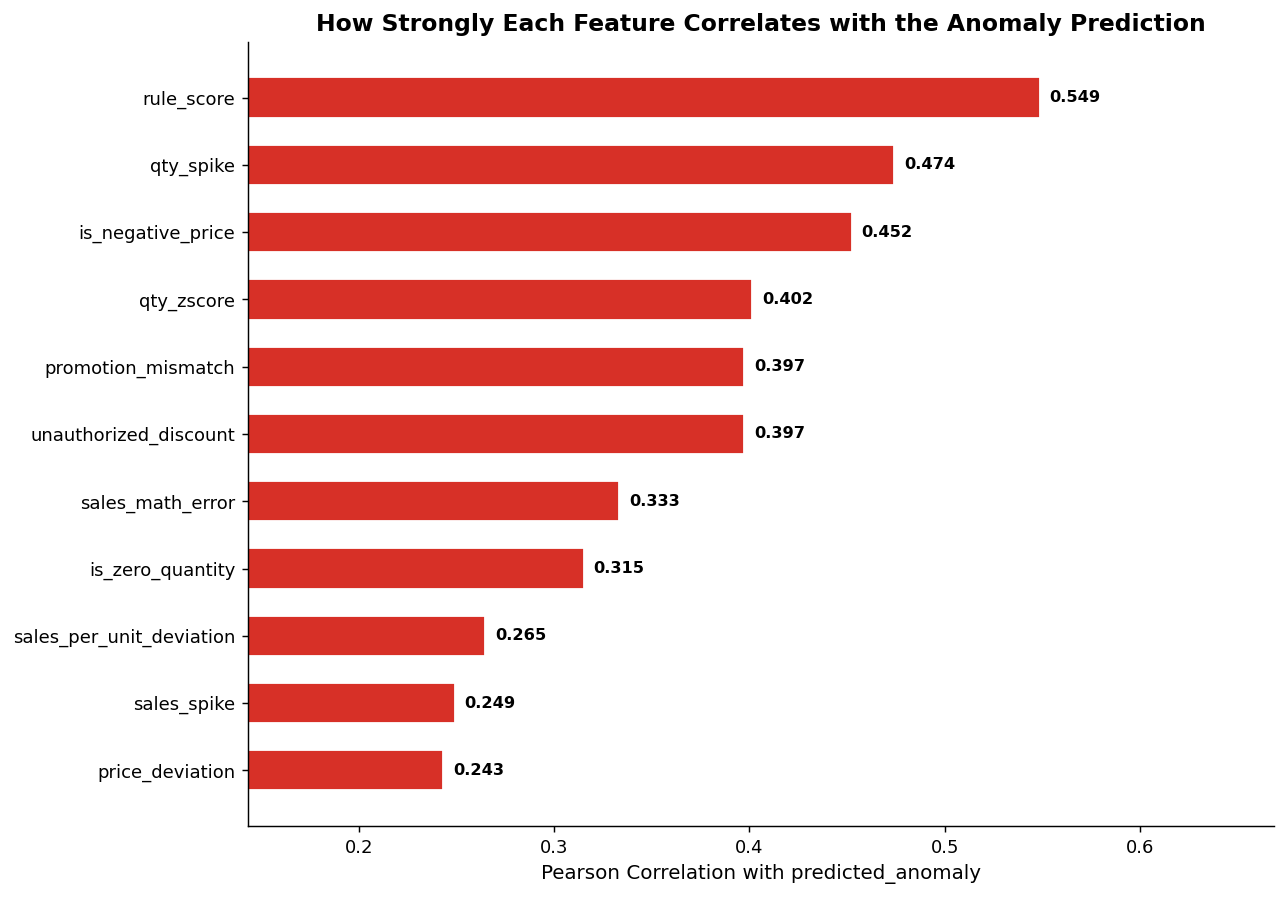

In [11]:

# ═══════════════════════════════════════════════════════════════════════════════
# VIZ 3 — FEATURES vs PREDICTED ANOMALY (correlation bar chart, clean version)
# ═══════════════════════════════════════════════════════════════════════════════

corr_with_pred = (
    df[viz_cols + ["predicted_anomaly"]]
    .corr()["predicted_anomaly"]
    .drop("predicted_anomaly")
    .sort_values(ascending=True)
)

colors_bar = ["#d73027" if v > 0 else "#4575b4" for v in corr_with_pred.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr_with_pred.index, corr_with_pred.values,
               color=colors_bar, edgecolor="white", height=0.6)
ax.axvline(0, color="#333", linewidth=1)
ax.set_xlabel("Pearson Correlation with predicted_anomaly")
ax.set_title("How Strongly Each Feature Correlates with the Anomaly Prediction",
             fontsize=13)

for bar, val in zip(bars, corr_with_pred.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha, fontsize=9, fontweight="bold")

ax.set_xlim(corr_with_pred.min() - 0.1, corr_with_pred.max() + 0.12)

# Annotation
top_feat = corr_with_pred.idxmax()
ax.annotate(f"← Strongest signal: {top_feat}",
            xy=(corr_with_pred.max(), len(corr_with_pred) - 1),
            xytext=(corr_with_pred.max() - 0.15, len(corr_with_pred) - 1.8),
            fontsize=9, color="#d73027",
            arrowprops=dict(arrowstyle="->", color="#d73027", lw=1.2))

plt.tight_layout()
plt.savefig("output/viz_3_feature_vs_prediction.png", dpi=150, bbox_inches="tight")
plt.show()


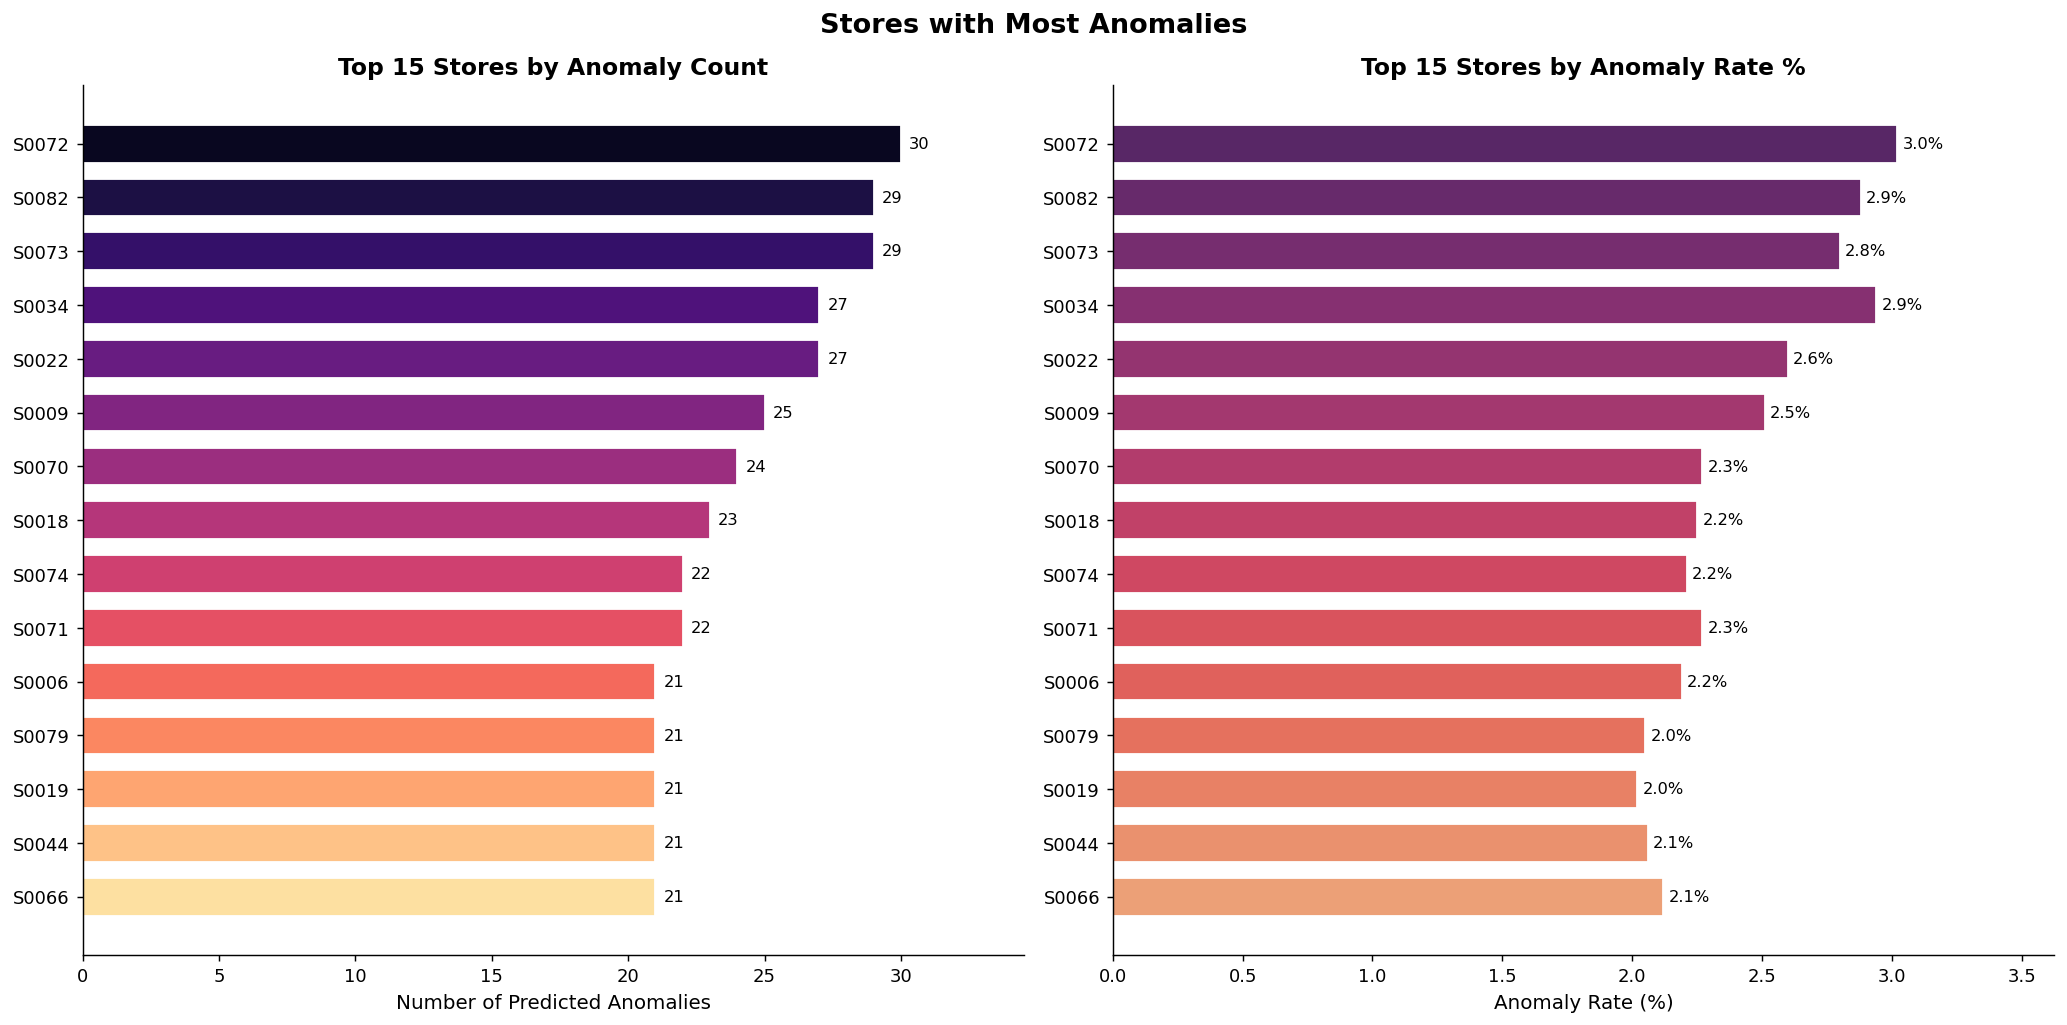

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIZ 4 — STORES WITH MOST ANOMALIES (count + rate side by side)
# ═══════════════════════════════════════════════════════════════════════════════

TOP_N = 15

store_counts = (
    anomalies_df.groupby("store_id").size()
    .sort_values(ascending=False).head(TOP_N)
    .reset_index(name="anomaly_count")
)
store_total = df.groupby("store_id").size().reset_index(name="total_rows")
store_counts = store_counts.merge(store_total, on="store_id")
store_counts["anomaly_rate_pct"] = (
    store_counts["anomaly_count"] / store_counts["total_rows"] * 100
).round(2)
store_counts = store_counts.sort_values("anomaly_count", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Stores with Most Anomalies", fontsize=15, fontweight="bold")

# Left: count
palette_l = sns.color_palette("magma_r", TOP_N)
bars_l = axes[0].barh(store_counts["store_id"], store_counts["anomaly_count"],
                      color=palette_l, edgecolor="white", height=0.7)
axes[0].set_xlabel("Number of Predicted Anomalies")
axes[0].set_title(f"Top {TOP_N} Stores by Anomaly Count")
for bar, row in zip(bars_l, store_counts.itertuples()):
    axes[0].text(row.anomaly_count + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 str(row.anomaly_count), va="center", fontsize=9)
axes[0].set_xlim(0, store_counts["anomaly_count"].max() * 1.15)

# Right: rate %
palette_r = sns.color_palette("flare", TOP_N)
bars_r = axes[1].barh(store_counts["store_id"], store_counts["anomaly_rate_pct"],
                      color=palette_r, edgecolor="white", height=0.7)
axes[1].set_xlabel("Anomaly Rate (%)")
axes[1].set_title(f"Top {TOP_N} Stores by Anomaly Rate %")
for bar, row in zip(bars_r, store_counts.itertuples()):
    axes[1].text(row.anomaly_rate_pct + 0.02,
                 bar.get_y() + bar.get_height()/2,
                 f"{row.anomaly_rate_pct:.1f}%", va="center", fontsize=9)
axes[1].set_xlim(0, store_counts["anomaly_rate_pct"].max() * 1.2)

plt.tight_layout()
plt.savefig("output/viz_4_store_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()



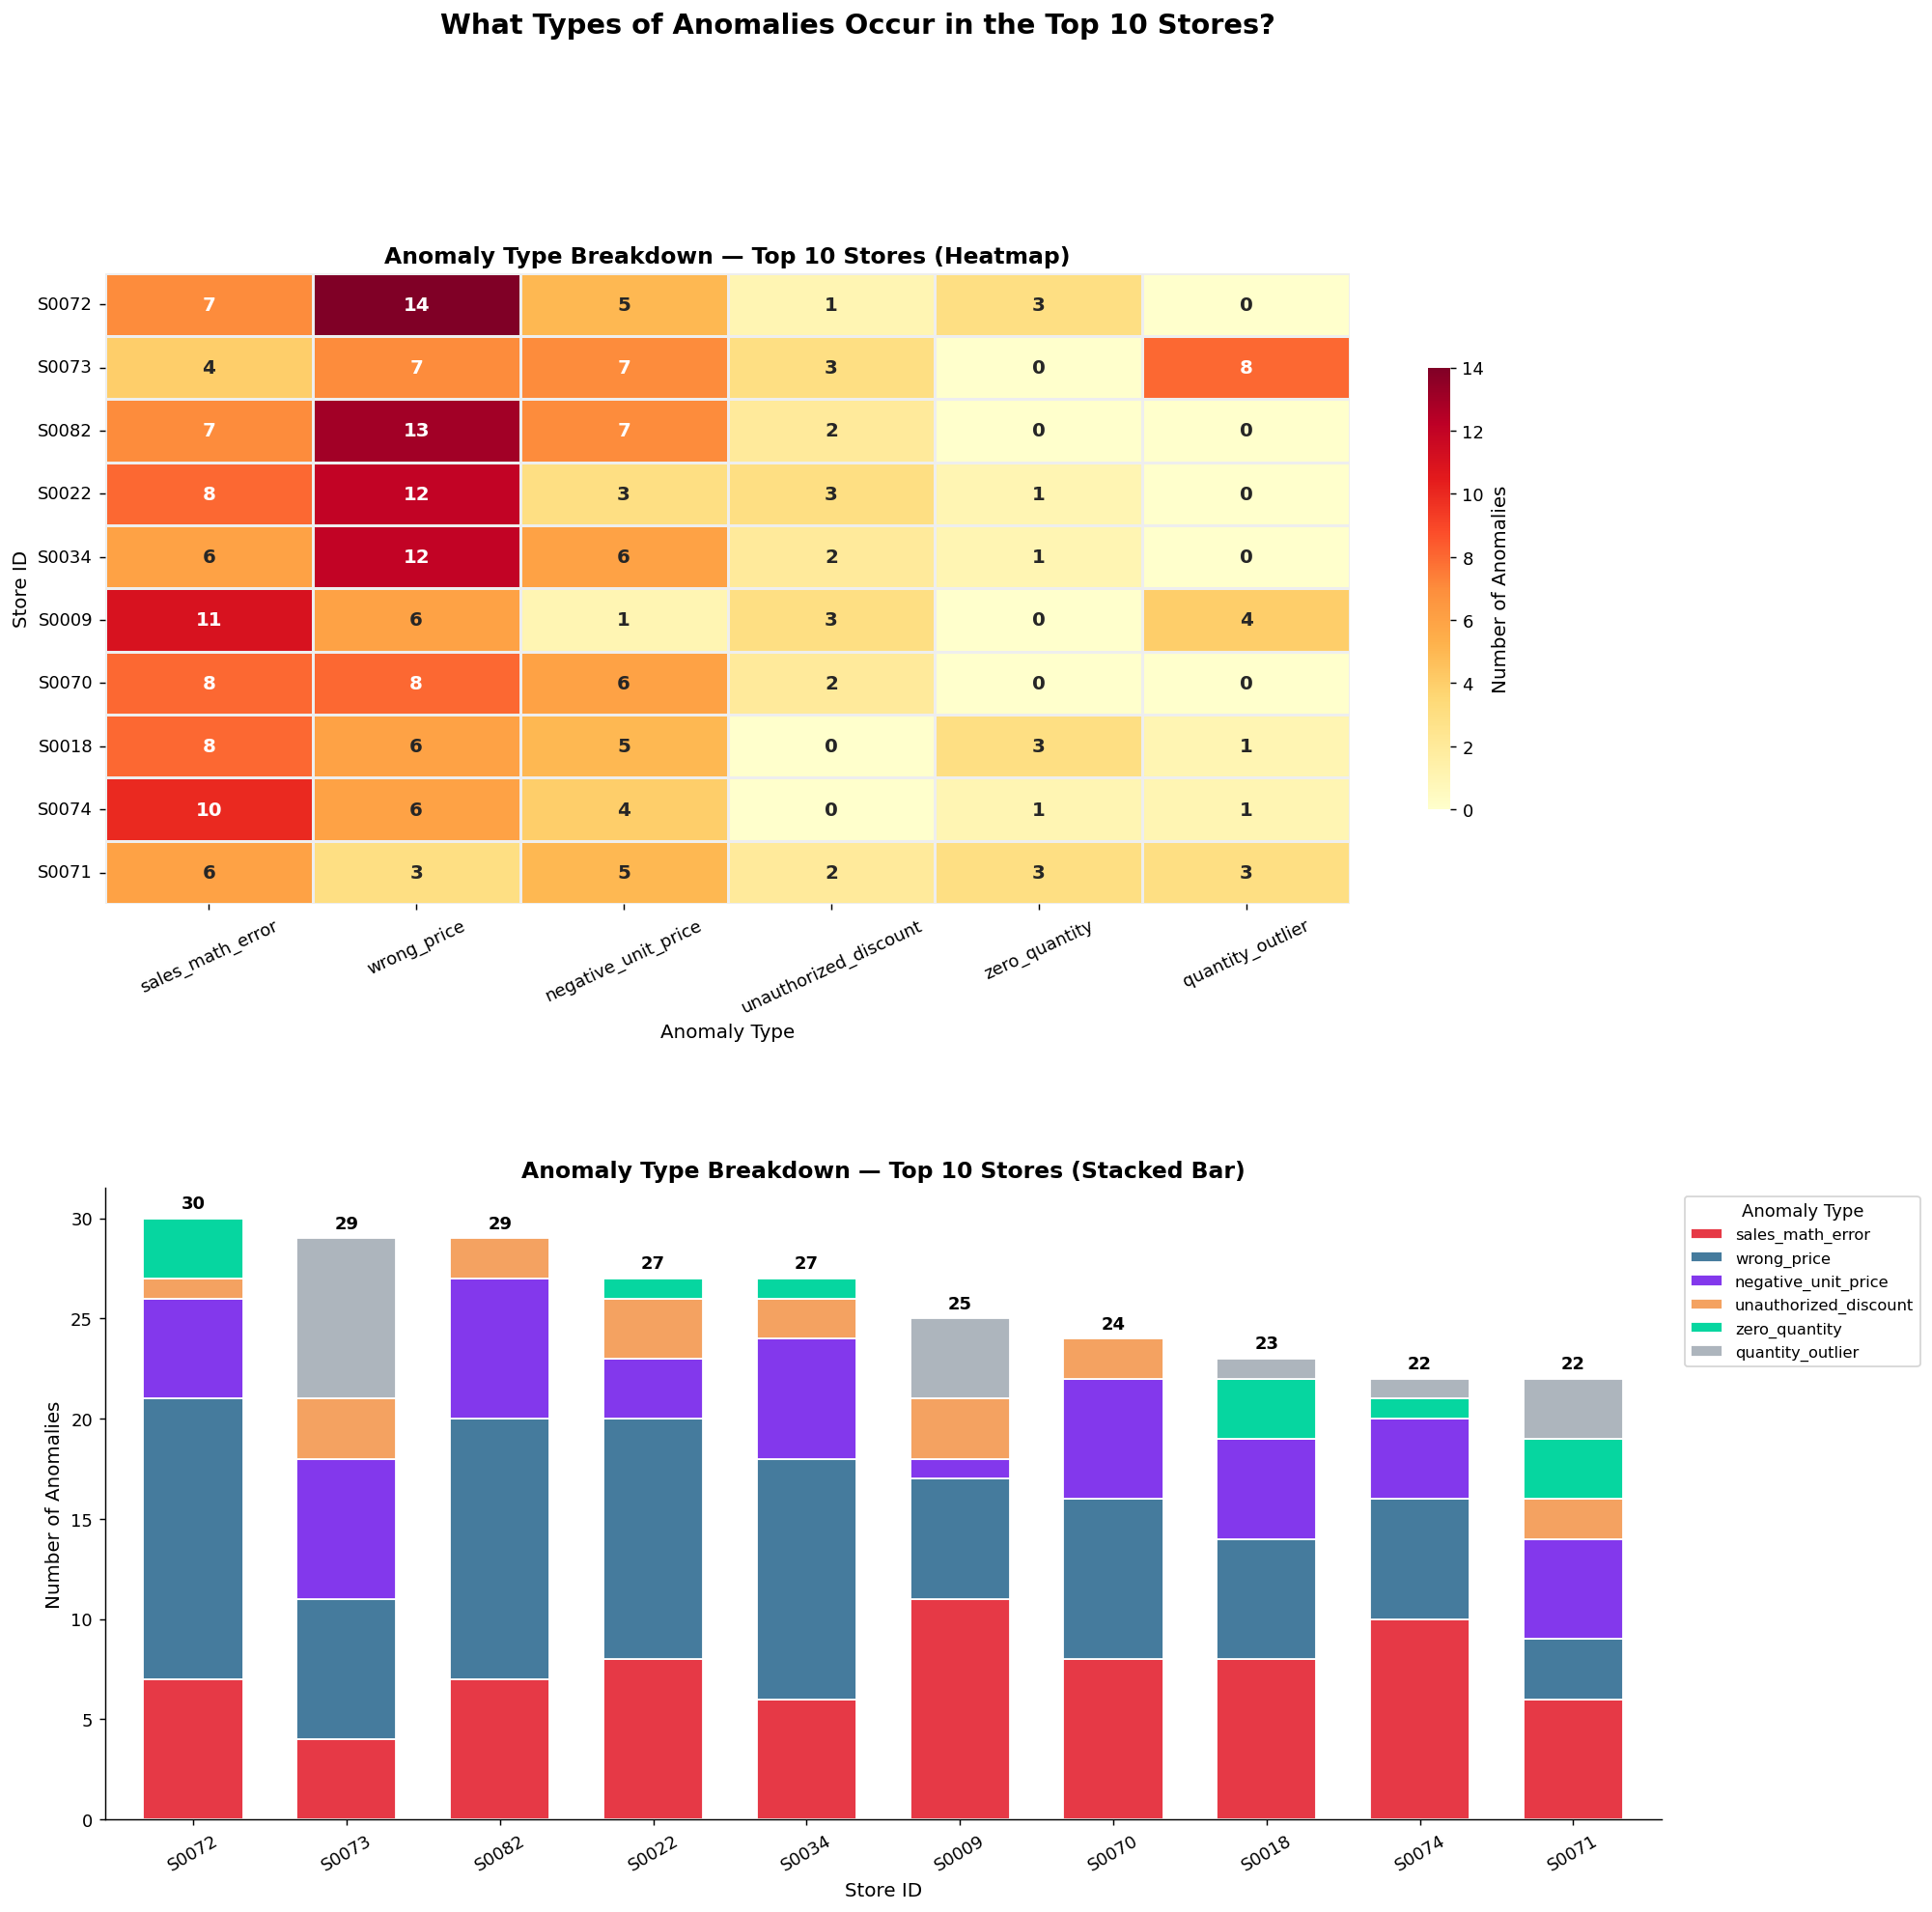

In [13]:

# ═══════════════════════════════════════════════════════════════════════════════
# VIZ 5 — ANOMALY TYPES PER TOP STORE (heatmap + stacked bar, no "normal")
# ═══════════════════════════════════════════════════════════════════════════════

TOP_N_STORES = 10

top_stores = (
    anomalies_df.groupby("store_id").size()
    .sort_values(ascending=False).head(TOP_N_STORES).index.tolist()
)

top_store_anomalies = anomalies_df[
    anomalies_df["store_id"].isin(top_stores)
].copy()

pivot = (
    top_store_anomalies.groupby(["store_id", "predicted_type"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(top_stores)
pivot = pivot[[c for c in ANOMALY_TYPES if c in pivot.columns]]

fig = plt.figure(figsize=(16, 16))
fig.suptitle(f"What Types of Anomalies Occur in the Top {TOP_N_STORES} Stores?",
             fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45)

# Heatmap
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    pivot,
    annot=True, fmt="d",
    cmap="YlOrRd", linewidths=0.6, linecolor="#eee",
    cbar_kws={"label": "Number of Anomalies", "shrink": 0.7},
    annot_kws={"size": 11, "weight": "bold"},
    ax=ax1,
)
ax1.set_title(f"Anomaly Type Breakdown — Top {TOP_N_STORES} Stores (Heatmap)", fontsize=13)
ax1.set_xlabel("Anomaly Type", fontsize=11)
ax1.set_ylabel("Store ID", fontsize=11)
ax1.tick_params(axis="x", rotation=25)
ax1.tick_params(axis="y", rotation=0)

# Stacked bar (no "normal")
ax2 = fig.add_subplot(gs[1])
bar_colors = [TYPE_COLORS.get(c, "#aaa") for c in pivot.columns]
pivot.plot(
    kind="bar", stacked=True, ax=ax2,
    color=bar_colors, width=0.65, edgecolor="white",
)
ax2.set_title(f"Anomaly Type Breakdown — Top {TOP_N_STORES} Stores (Stacked Bar)", fontsize=13)
ax2.set_xlabel("Store ID", fontsize=11)
ax2.set_ylabel("Number of Anomalies", fontsize=11)
ax2.tick_params(axis="x", rotation=30)
ax2.legend(title="Anomaly Type", bbox_to_anchor=(1.01, 1),
           loc="upper left", fontsize=9, title_fontsize=10)

# Add total labels on top of each bar
for i, store in enumerate(pivot.index):
    total = pivot.loc[store].sum()
    ax2.text(i, total + 0.3, str(total), ha="center", va="bottom",
             fontsize=10, fontweight="bold")

plt.savefig("output/viz_5_store_anomaly_types.png", dpi=150, bbox_inches="tight")
plt.show()


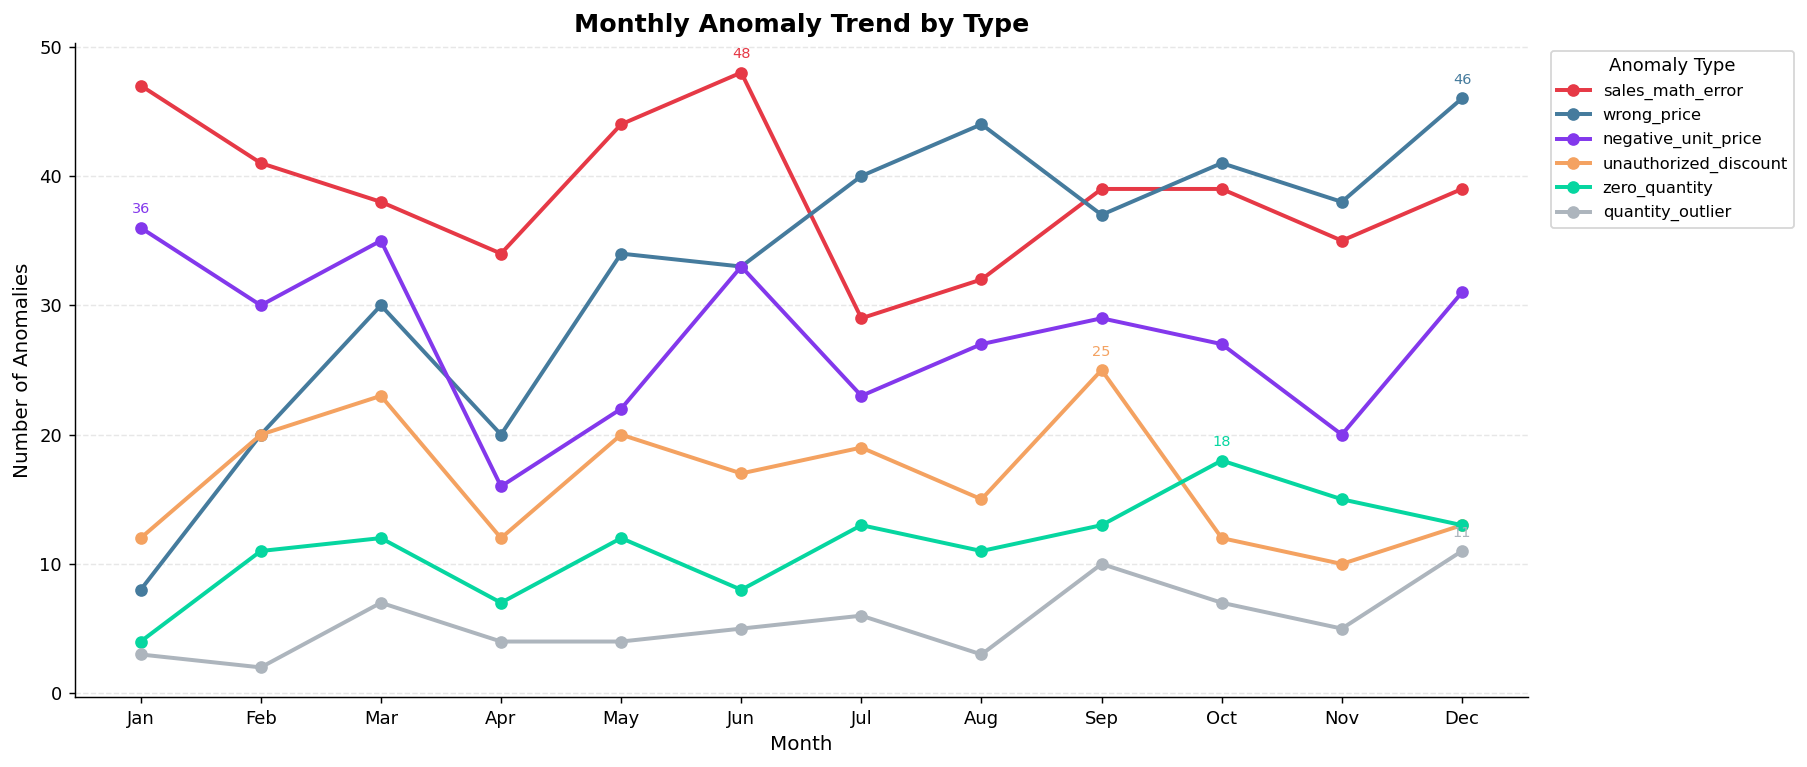

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIZ 6 — ANOMALY TREND BY MONTH (line chart per type)
# ═══════════════════════════════════════════════════════════════════════════════

month_type = (
    anomalies_df.groupby(["month", "predicted_type"])
    .size().unstack(fill_value=0)
)
month_type = month_type[[c for c in ANOMALY_TYPES if c in month_type.columns]]

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
month_type.index = [month_labels[m-1] for m in month_type.index]

fig, ax = plt.subplots(figsize=(14, 6))
for col in month_type.columns:
    ax.plot(month_type.index, month_type[col],
            marker="o", linewidth=2.2, markersize=6,
            color=TYPE_COLORS.get(col, "#aaa"), label=col)
    # Annotate peak month
    peak_idx = month_type[col].idxmax()
    peak_val = month_type[col].max()
    ax.annotate(f"{peak_val}",
                xy=(peak_idx, peak_val),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8,
                color=TYPE_COLORS.get(col, "#aaa"))

ax.set_title("Monthly Anomaly Trend by Type", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Anomalies")
ax.legend(title="Anomaly Type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("output/viz_6_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY PRINT
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 55)
print("  VISUALIZATION SUMMARY")
print("=" * 55)
print(f"\n  Total rows          : {len(df):,}")
print(f"  Flagged anomalies   : {len(anomalies_df):,} ({len(anomalies_df)/len(df)*100:.2f}%)")
print(f"\n  Anomaly type counts (anomalies only):")
print(anomalies_df["predicted_type"].value_counts().to_frame("count").to_string())
print(f"\n  Saved:")
for i in range(1, 7):
    print(f"    output/viz_{i}_*.png")

  VISUALIZATION SUMMARY

  Total rows          : 100,768
  Flagged anomalies   : 1,587 (1.57%)

  Anomaly type counts (anomalies only):
                       count
predicted_type              
sales_math_error         465
wrong_price              391
negative_unit_price      329
unauthorized_discount    198
zero_quantity            137
quantity_outlier          67

  Saved:
    output/viz_1_*.png
    output/viz_2_*.png
    output/viz_3_*.png
    output/viz_4_*.png
    output/viz_5_*.png
    output/viz_6_*.png
